GBM
부스팅 알고리즘으로 에이타 부스트와 그래디언트 부스트가 있고 
에이다 부스트는 오류데이터에 가중치 부여하면서 부스팅, 그래디언트 부스트는 가중치 업데이트를 경사하강법을 이용

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')

    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
        lambda x : x['column_name'] + '_' + str(x['dup_cnt']) if x['dup_cnt'] > 0 else x['column_name'], axis=1
    )
    
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

def get_human_dataset():
    feature_name_df=pd.read_csv('./human_activity/features.txt',sep='\s+',header=None,names=['column_index','column_name'])
    new_feature_name_df=get_new_feature_name_df(feature_name_df)
    feature_name=new_feature_name_df.iloc[:,1].values.tolist()
    X_train=pd.read_csv('./human_activity/train/X_train.txt',sep='\s+',names=feature_name)
    X_test=pd.read_csv('./human_activity/test/X_test.txt',sep='\s+',names=feature_name)
    y_train=pd.read_csv('./human_activity/train/y_train.txt',sep='\s+',header=None,names=['action'])
    y_test=pd.read_csv('./human_activity/test/y_test.txt',sep='\s+',header=None,names=['action'])
    return X_train,X_test,y_train,y_test

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train,X_test,y_train,y_test=get_human_dataset()

#GBM 수행시간 측정을 위함. 시작시간 설정
start_time=time.time()

gb_clf=GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train,y_train)
gb_pred=gb_clf.predict(X_test)
gb_accuracy=accuracy_score(y_test,gb_pred)

print('랜덤 포레스트 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행시간:{0:.1f}초".format(time.time()-start_time))



KeyboardInterrupt: 

In [2]:
import xgboost as xgb
from xgboost import XGBClassifier

In [3]:
import xgboost
print(xgboost.__version__)

3.2.0


In [4]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features= dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target']= labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [5]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())


['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [6]:
#cancer_df에서 feature용 dataframe과 label용 series 객체 추출
#맨 마지막 칼럼이 label, feature용 dataframe은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째칼럼까지를 :-1 슬라이싱으로 추출
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]

#전체 데이터중에서 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label,test_size=0.2, random_state=156 )
# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )
print(X_train.shape , X_test.shape)
print(X_tr.shape, X_val.shape)
                                         

(455, 30) (114, 30)
(409, 30) (46, 30)


In [7]:
#만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안될 경우 X_train.values로 넘파이 변환
#학습, 검증, 테스트용 DMatrix를 생성
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test , label=y_test)

In [8]:
params={'max_depth':3,
        'eta': 0.05,
        'objective':'binary:logistic',
        'eval_metric':'logloss'
        }
num_rounds=400


In [9]:
#학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다
eval_list = [(dtr,'train'),(dval,'eval')]

#하이퍼 파라미터와 early stopping 파라미터를 train( ) 함수의 파라미터로 전달
xgb_model = xgb.train(params = params , dtrain=dtr , num_boost_round=num_rounds , early_stopping_rounds=50, evals=eval_list)


[0]	train-logloss:0.62473	eval-logloss:0.63088


[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[21]	train-logloss:0.21335	eval-logloss:0.34726
[

In [10]:
pred_probs = xgb_model.predict(dtest)
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5 보다 크면 1 , 그렇지 않으면 0 으로 예측값 결정하여 List 객체인 preds에 저장 
preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print('예측값 10개만 표시:',preds[:10])

predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

get_clf_eval(y_test , preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC:0.9965


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

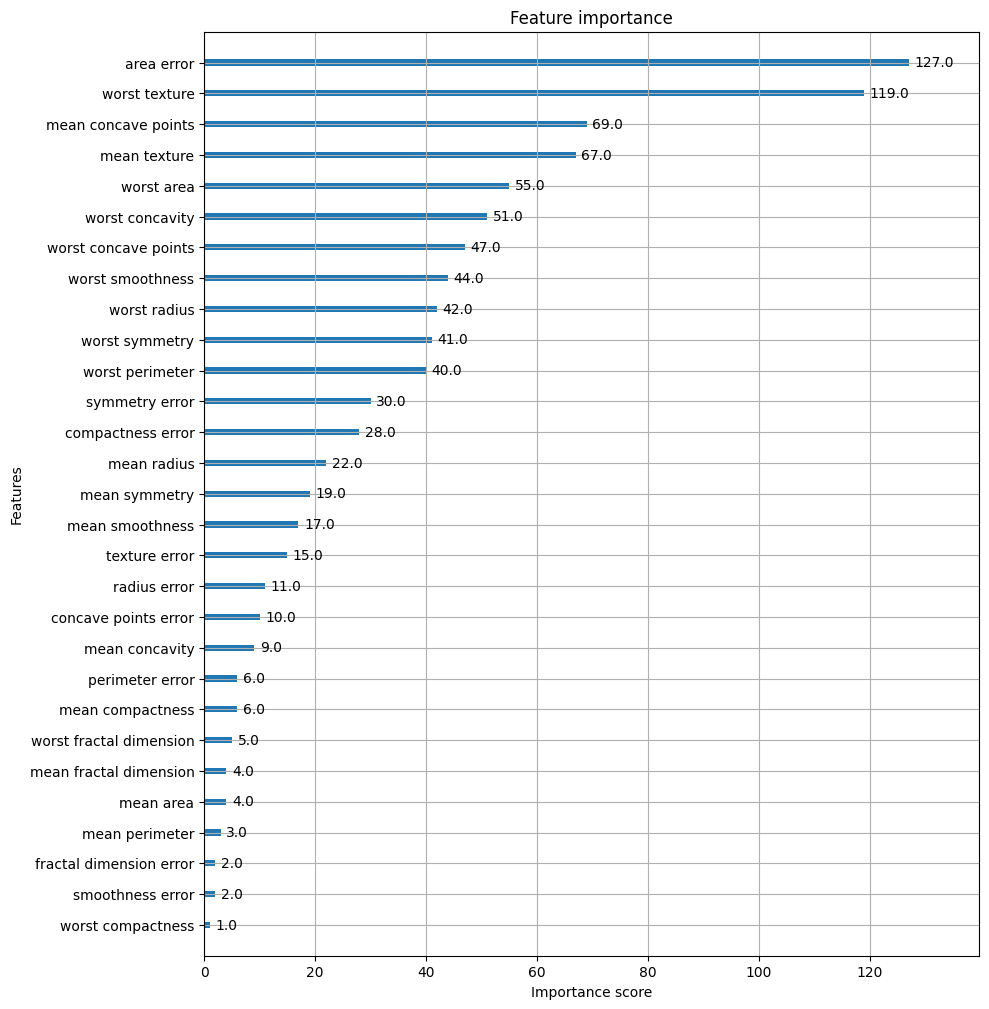

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax=plt.subplots(figsize=(10,12))
plot_importance(xgb_model,ax=ax)


In [13]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

#warning메시지를 없애기 위해 eval_metric 값을 xgbclassifier 생성인자로 입력
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [14]:
get_clf_eval(y_test,w_preds,w_pred_proba)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870,    F1: 0.9806, AUC:0.9951


In [16]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,early_stopping_rounds=50,eval_metric="logloss",)                         
evals = [(X_tr, y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)
ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.58448	validation_1-logloss:0.60406
[1]	validation_0-logloss:0.51755	validation_1-logloss:0.55810
[2]	validation_0-logloss:0.46160	validation_1-logloss:0.51829
[3]	validation_0-logloss:0.41227	validation_1-logloss:0.48332
[4]	validation_0-logloss:0.37097	validation_1-logloss:0.45158
[5]	validation_0-logloss:0.33550	validation_1-logloss:0.42452
[6]	validation_0-logloss:0.30431	validation_1-logloss:0.40638
[7]	validation_0-logloss:0.27728	validation_1-logloss:0.38845
[8]	validation_0-logloss:0.25301	validation_1-logloss:0.37252
[9]	validation_0-logloss:0.23069	validation_1-logloss:0.35833
[10]	validation_0-logloss:0.21102	validation_1-logloss:0.34634
[11]	validation_0-logloss:0.19422	validation_1-logloss:0.33539
[12]	validation_0-logloss:0.17862	validation_1-logloss:0.32481
[13]	validation_0-logloss:0.16474	validation_1-logloss:0.31769
[14]	validation_0-logloss:0.15249	validation_1-logloss:0.31101
[15]	validation_0-logloss:0.14137	validation_1-logloss:0.30528
[1

In [17]:
get_clf_eval(y_test,ws50_preds,ws50_pred_proba)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC:0.9965


In [18]:
# early_stopping_rounds를 10으로 설정하고 재학습. 
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,
                            eval_metric="logloss", early_stopping_rounds=10)
xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test , ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.58402	validation_1-logloss:0.58549
[1]	validation_0-logloss:0.51711	validation_1-logloss:0.53228
[2]	validation_0-logloss:0.46159	validation_1-logloss:0.48892
[3]	validation_0-logloss:0.41327	validation_1-logloss:0.44928
[4]	validation_0-logloss:0.37176	validation_1-logloss:0.41012
[5]	validation_0-logloss:0.33607	validation_1-logloss:0.38031
[6]	validation_0-logloss:0.30537	validation_1-logloss:0.35208
[7]	validation_0-logloss:0.27785	validation_1-logloss:0.32537
[8]	validation_0-logloss:0.25372	validation_1-logloss:0.30683
[9]	validation_0-logloss:0.23258	validation_1-logloss:0.28687
[10]	validation_0-logloss:0.21382	validation_1-logloss:0.26871
[11]	validation_0-logloss:0.19659	validation_1-logloss:0.25388
[12]	validation_0-logloss:0.18161	validation_1-logloss:0.23967
[13]	validation_0-logloss:0.16783	validation_1-logloss:0.22651
[14]	validation_0-logloss:0.15560	validation_1-logloss:0.21699
[15]	validation_0-logloss:0.14488	validation_1-logloss:0.20480
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

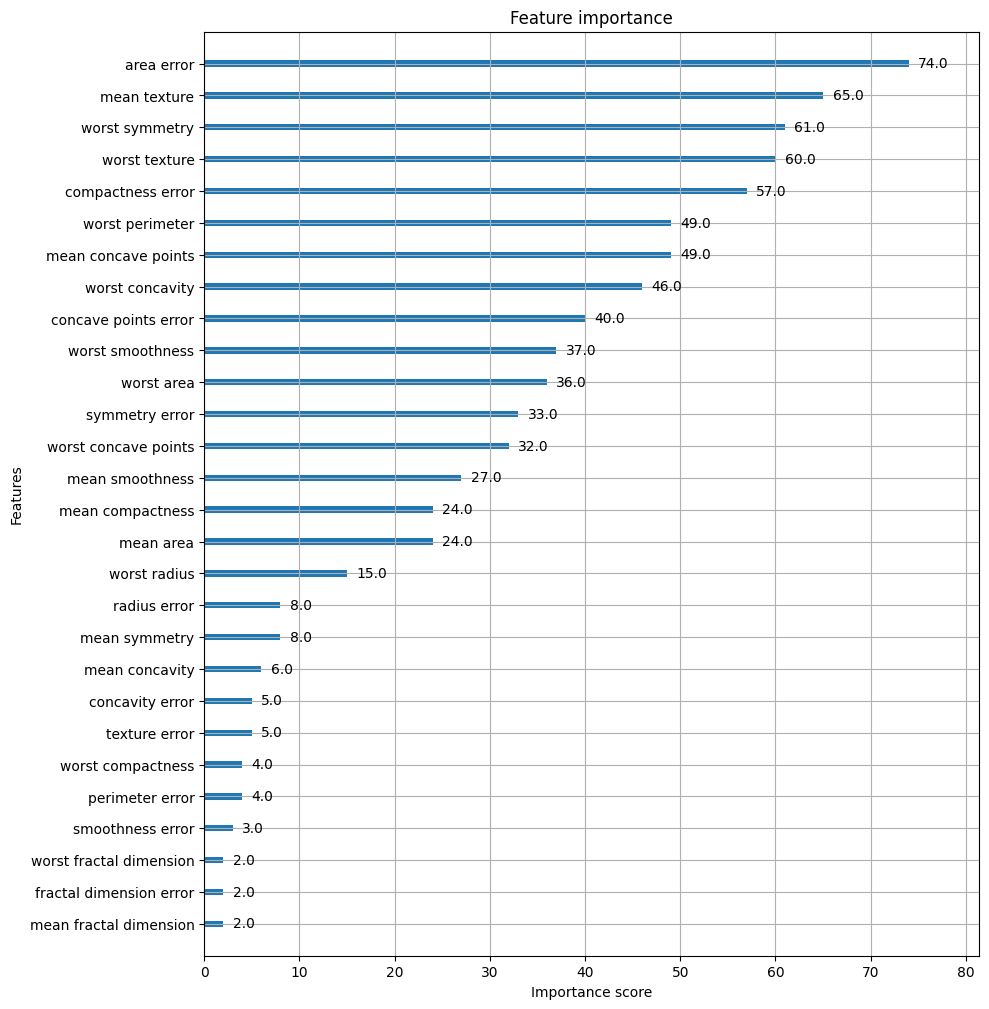

In [19]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
# 사이킷런 래퍼 클래스를 입력해도 무방. 
plot_importance(xgb_wrapper, ax=ax)

LightGBM

In [20]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능.
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(
    X_tr,
    y_tr,
    eval_metric="logloss",
    eval_set=evals,
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=1)]
)
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.

In [21]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9877


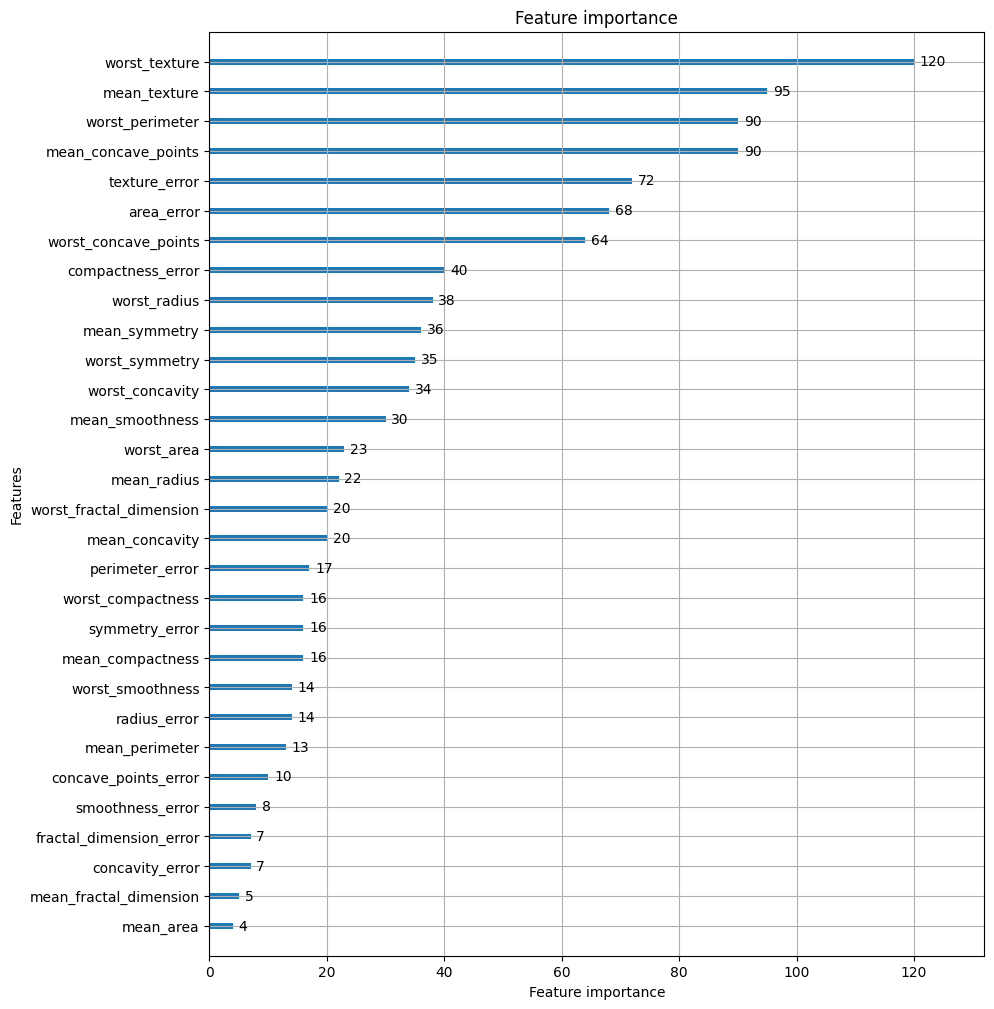

In [22]:
# plot_importance( )를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)
plt.savefig('lightgbm_feature_importance.tif', format='tif', dpi=300, bbox_inches='tight')